# Iris Task

## PART 1


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import confusion_matrix

### Helper functions

In [38]:
# Loading Iris data from file
def load_iris(filepath="iris.data"):
    X = []
    y = []

    label_map = {
        "Iris-setosa": 0,
        "Iris-versicolor": 1,
        "Iris-virginica": 2
    }

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",")
            X.append([float(v) for v in parts[:4]])
            y.append(label_map[parts[4]])

    return np.array(X, dtype=float), np.array(y, dtype=int)

# One-hot encoding
def one_hot(y, num_classes=3):
    T = np.zeros((len(y), num_classes))
    T[np.arange(len(y)), y] = 1
    return T


def add_bias(X):
    return np.hstack([X, np.ones((X.shape[0], 1))])


def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))


def mse(G, T):
    return 0.5 * np.sum((G - T) ** 2)


def train_linear_classifier(X_train, y_train, alpha=0.01, max_iter=1000, tol=1e-8):
    T = one_hot(y_train, num_classes=3)

    Xb = add_bias(X_train)
    _, D = Xb.shape
    C = T.shape[1]

    rng = np.random.default_rng(42)
    W = 0.01 * rng.standard_normal((C, D))

    mse_history = []

    for it in range(max_iter):
        Z = Xb @ W.T
        G = sigmoid(Z)

        current_mse = mse(G, T)
        mse_history.append(current_mse)

        delta = (G - T) * G * (1.0 - G)
        grad = delta.T @ Xb

        W_new = W - alpha * grad

        if it > 0 and abs(mse_history[-2] - mse_history[-1]) < tol:
            W = W_new
            break

        W = W_new

    return W, mse_history


def predict(W, X):
    Xb = add_bias(X)
    G = sigmoid(Xb @ W.T)
    return np.argmax(G, axis=1)


def error_rate(y_true, y_pred):
    return np.mean(y_true != y_pred)


def run_alpha_experiment(X_train, y_train, X_test, y_test, alphas):
    results = {}

    for alpha in alphas:
        W, mse_hist = train_linear_classifier(X_train, y_train, alpha=alpha)

        y_train_pred = predict(W, X_train)
        y_test_pred = predict(W, X_test)

        train_cm = confusion_matrix(y_train, y_train_pred)
        test_cm = confusion_matrix(y_test, y_test_pred)

        results[alpha] = {
            "W": W,
            "mse_history": mse_hist,
            "train_cm": train_cm,
            "test_cm": test_cm,
            "train_error": error_rate(y_train, y_train_pred),
            "test_error": error_rate(y_test, y_test_pred),
            "iterations": len(mse_hist)
        }

    return results


def plot_mse_histories(results, case_name=""):
    plt.figure(figsize=(8, 5))
    for alpha, res in results.items():
        plt.plot(res["mse_history"], label=f"α={alpha}")
    plt.xlabel("Iteration")
    plt.ylabel("MSE")
    plt.title(f"{case_name}: Training MSE for different step lengths (α)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{case_name}_mse.pdf")
    plt.show()
    
    
def plot_confusion_matrix(cm, class_names, title, error_rate=None):
    plt.figure(figsize=(8, 6))
    sn.heatmap(cm, annot=True, fmt="d", cmap="Blues",
               xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    if error_rate is None:
        plt.title(title)
    else:
        plt.title(f"{title}\nError rate = {error_rate:.2%}")
    plt.tight_layout()
    plt.savefig(f"{title}_cm.pdf")
    plt.show()
    
def run_case(X, y, split_function, alphas, case_name):
    X_train, y_train, X_test, y_test = split_function(X, y)
    results = run_alpha_experiment(X_train, y_train, X_test, y_test, alphas)
    plot_mse_histories(results, case_name)

    best_alpha = min(
        results,
        key=lambda a: (results[a]["train_error"], results[a]["mse_history"][-1])
    )
    best_res = results[best_alpha]

    print(f"\n{case_name}")
    print(f"Best alpha: {best_alpha}")
    print(f"Training error rate = {best_res['train_error']:.2%}")
    print(f"Test error rate     = {best_res['test_error']:.2%}")

    class_names = ["Setosa", "Versicolor", "Virginica"]
    plot_confusion_matrix(best_res["train_cm"], class_names,
                          f"{case_name}: Training", best_res["train_error"])
    plot_confusion_matrix(best_res["test_cm"], class_names,
                          f"{case_name}: Test", best_res["test_error"])

    return results, best_alpha, best_res

### Split 1: First 30 samples of each class for training, last 20 for testing

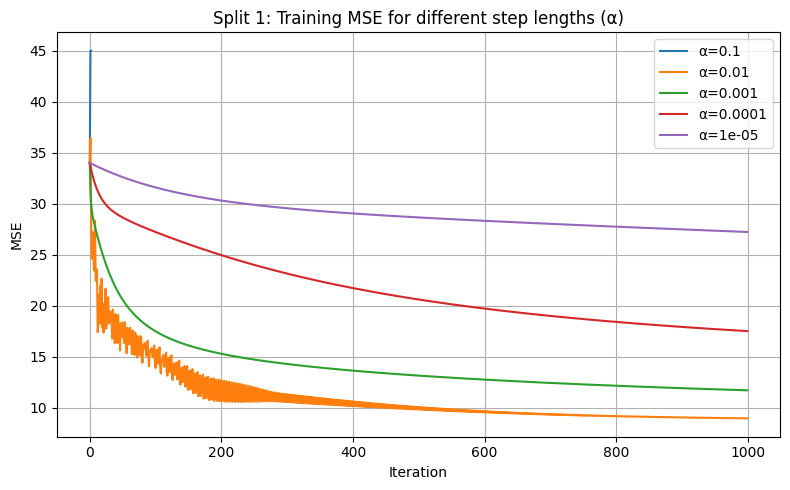


Split 1
Best alpha: 0.01
Training error rate = 3.33%
Test error rate     = 5.00%


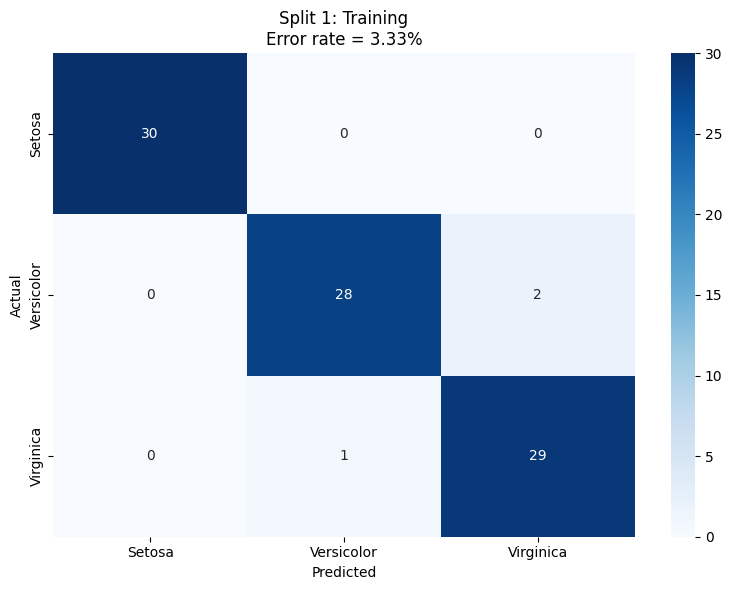

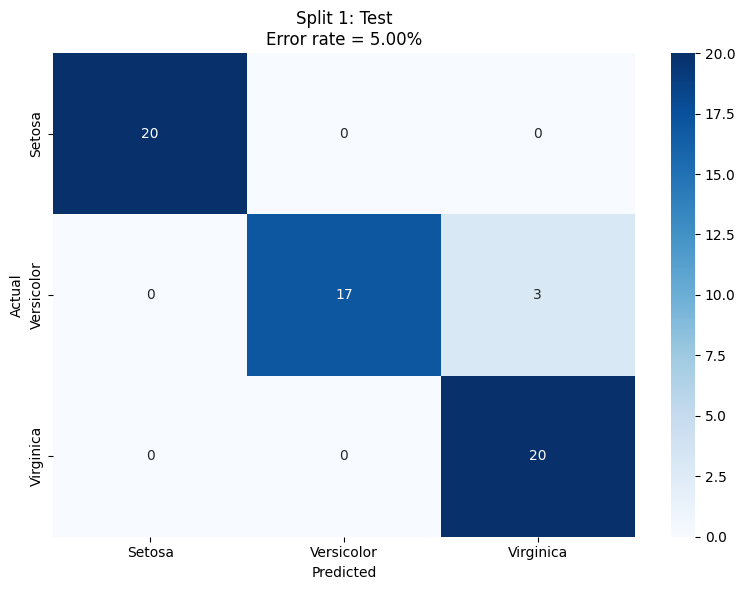

In [39]:
def split_first30_last20(X, y):
    X_train, y_train = [], []
    X_test, y_test = [], []

    for c in range(3):
        Xc = X[y == c]
        yc = y[y == c]

        X_train.append(Xc[:30])
        y_train.append(yc[:30])

        X_test.append(Xc[30:])
        y_test.append(yc[30:])

    X_train = np.vstack(X_train)
    y_train = np.concatenate(y_train)
    X_test = np.vstack(X_test)
    y_test = np.concatenate(y_test)

    return X_train, y_train, X_test, y_test

X, y = load_iris("iris.data")

alphas = [0.1, 0.01, 0.001, 0.0001, 0.00001]

results1, best_alpha1, best_res1 = run_case(
    X, y,
    split_first30_last20,
    alphas,
    "Split 1"
)

### Split 2: Last 30 samples of each class for training, first 20 for testing

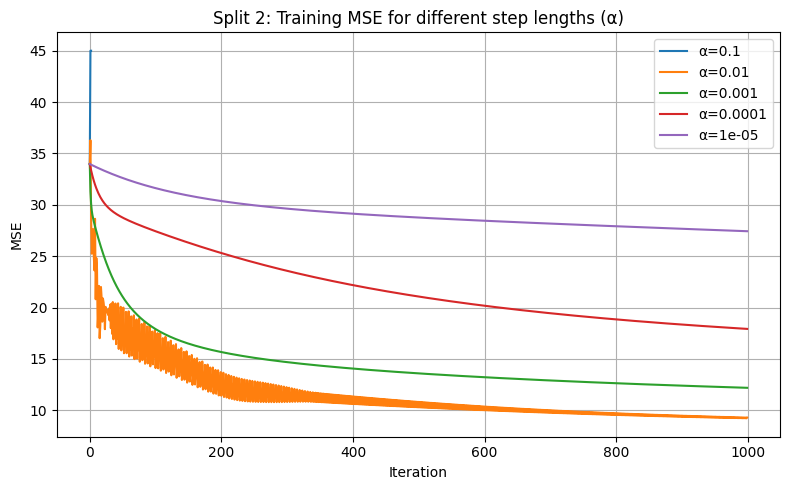


Split 2
Best alpha: 0.01
Training error rate = 5.56%
Test error rate     = 1.67%


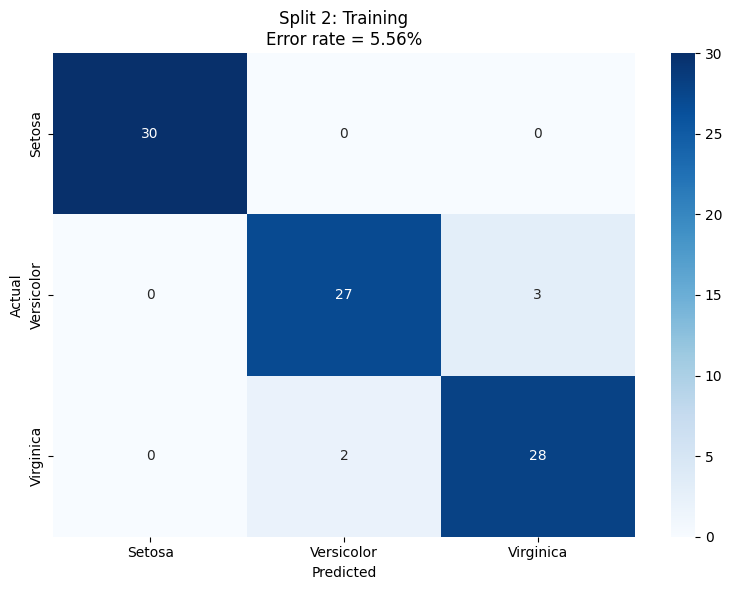

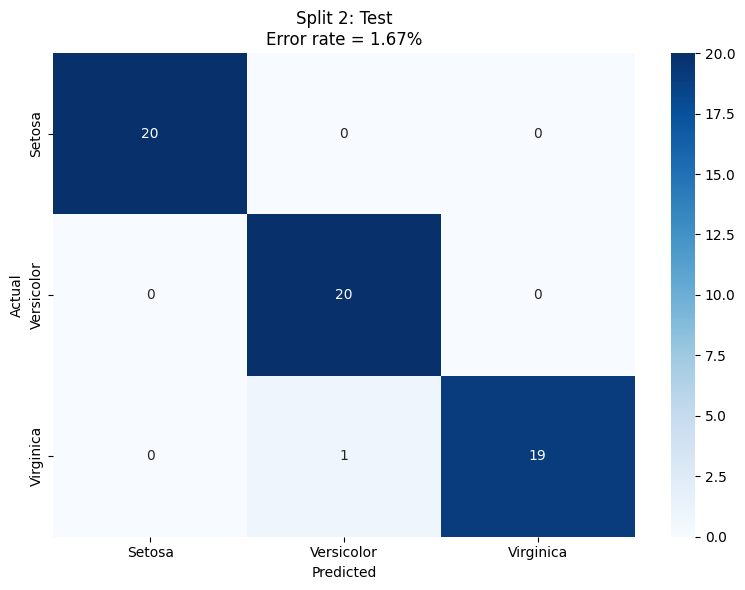

In [40]:
def split_last30_first20(X, y):
    X_train, y_train = [], []
    X_test, y_test = [], []
    
    for c in range(3):
        Xc = X[y == c]
        yc = y[y == c]

        X_train.append(Xc[20:])   # last 30
        y_train.append(yc[20:])

        X_test.append(Xc[:20])    # first 20
        y_test.append(yc[:20])

    X_train = np.vstack(X_train)
    y_train = np.concatenate(y_train)
    X_test = np.vstack(X_test)
    y_test = np.concatenate(y_test)

    return X_train, y_train, X_test, y_test


X, y = load_iris("iris.data")

alphas = [0.1, 0.01, 0.001, 0.0001, 0.00001]

results2, best_alpha2, best_res2 = run_case(
    X, y,
    split_last30_first20,
    alphas,
    "Split 2"
)

## PART 2

### Histograms of Iris Features for each class

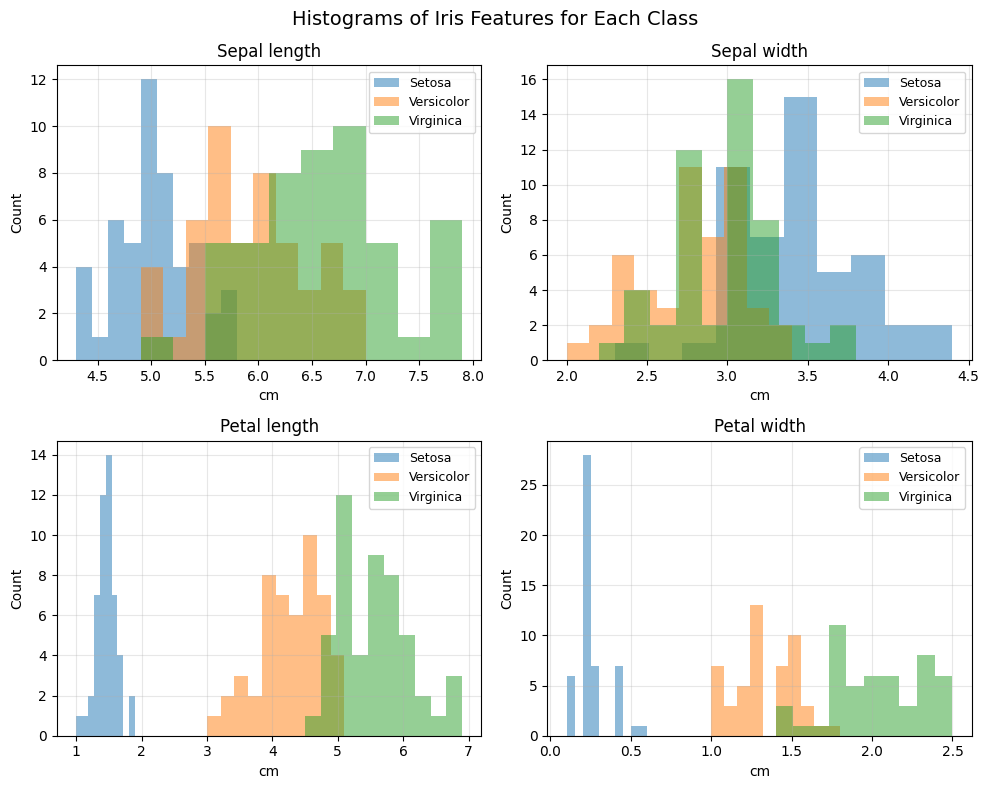

In [41]:
def plot_feature_histograms(X, y):
    feature_names = ["Sepal length", "Sepal width", "Petal length", "Petal width"]
    class_names = ["Setosa", "Versicolor", "Virginica"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for i in range(4):
        ax = axes[i]

        for c in range(3):
            ax.hist(
                X[y == c, i],
                bins=10,
                alpha=0.5,
                label=class_names[c]
            )

        ax.set_title(feature_names[i])
        ax.set_xlabel("cm")
        ax.set_ylabel("Count")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    fig.suptitle("Histograms of Iris Features for Each Class", fontsize=14)
    plt.tight_layout()
    plt.savefig("histograms.pdf")
    plt.show()

X, y = load_iris("iris.data")

plot_feature_histograms(X, y)

### Removal of sepal width
Sepal width is the feature with the most overlap between classes

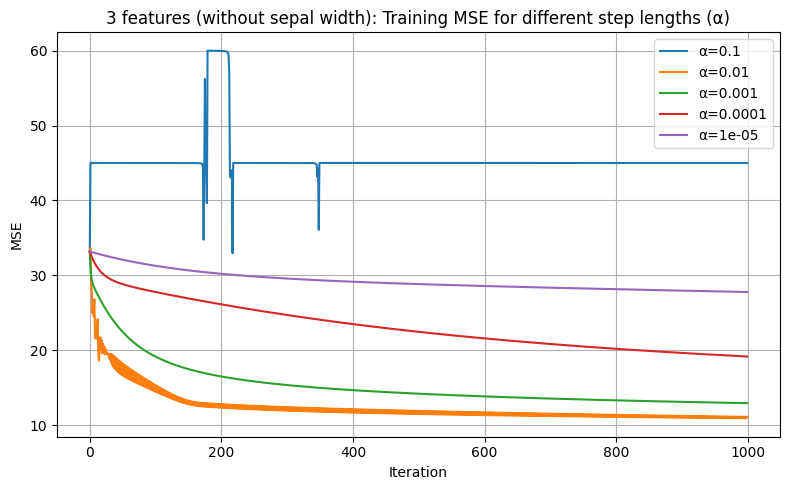


3 features (without sepal width)
Best alpha: 0.01
Training error rate = 3.33%
Test error rate     = 5.00%


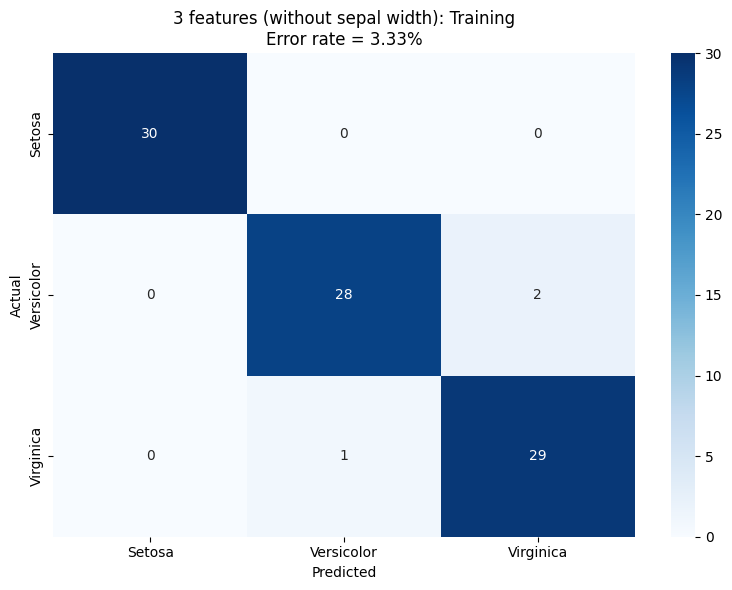

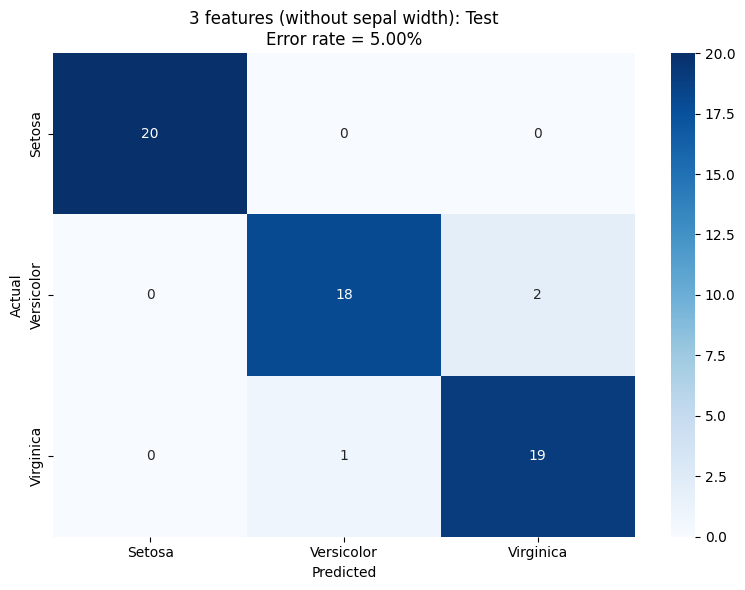

In [42]:
# 3 features: sepal length, petal length and petal width
X_3 = X[:, [0, 2, 3]]

results3, best_alpha3, best_res3 = run_case(
    X_3, y,
    split_first30_last20,
    alphas,
    "3 features (without sepal width)"
)

### Removal of sepal width and sepal length

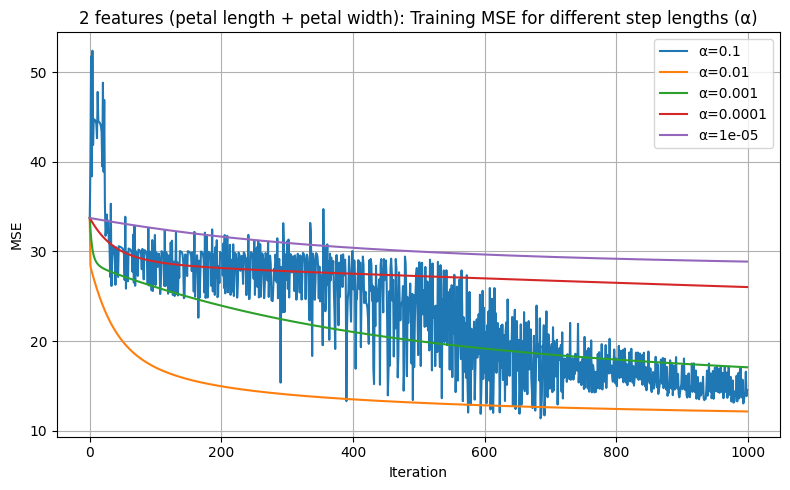


2 features (petal length + petal width)
Best alpha: 0.01
Training error rate = 6.67%
Test error rate     = 6.67%


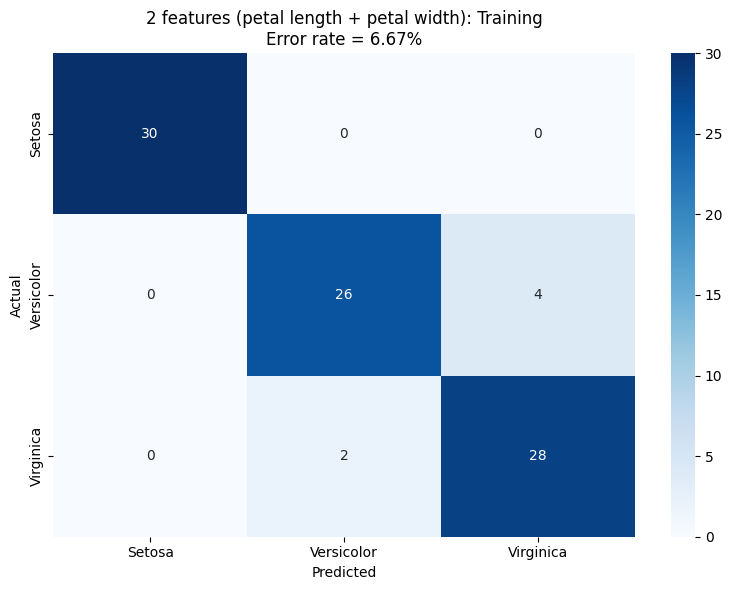

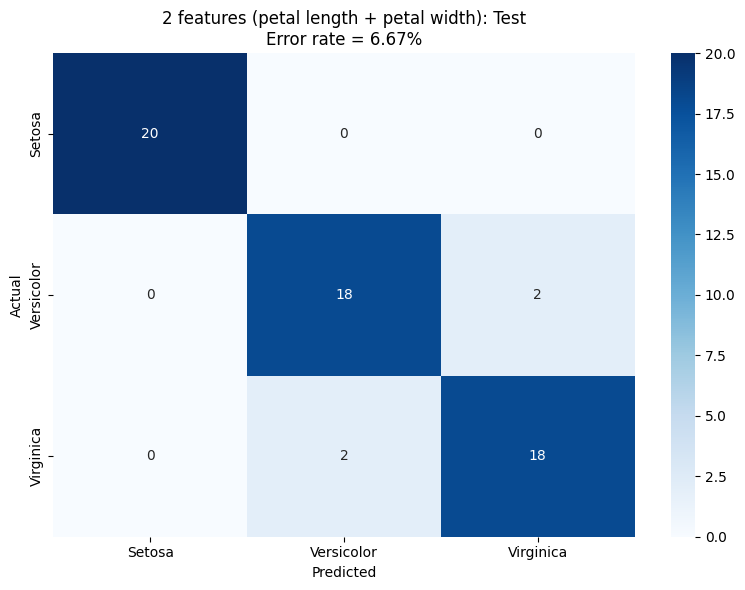

In [43]:
# 2 features: petal length and petal width
X_2 = X[:, [2, 3]] 

results2, best_alpha2, best_res2 = run_case(
    X_2, y,
    split_first30_last20,
    alphas,
    "2 features (petal length + petal width)"
)

### Removal of sepal width, sepal length and petal length

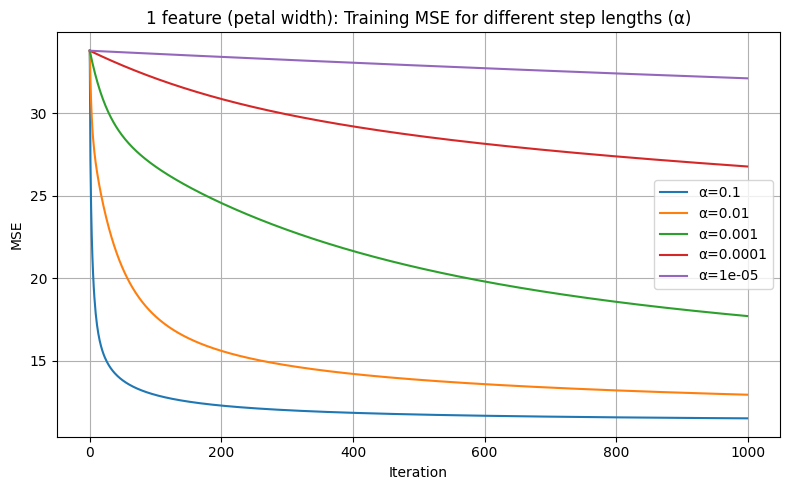


1 feature (petal width)
Best alpha: 0.1
Training error rate = 4.44%
Test error rate     = 6.67%


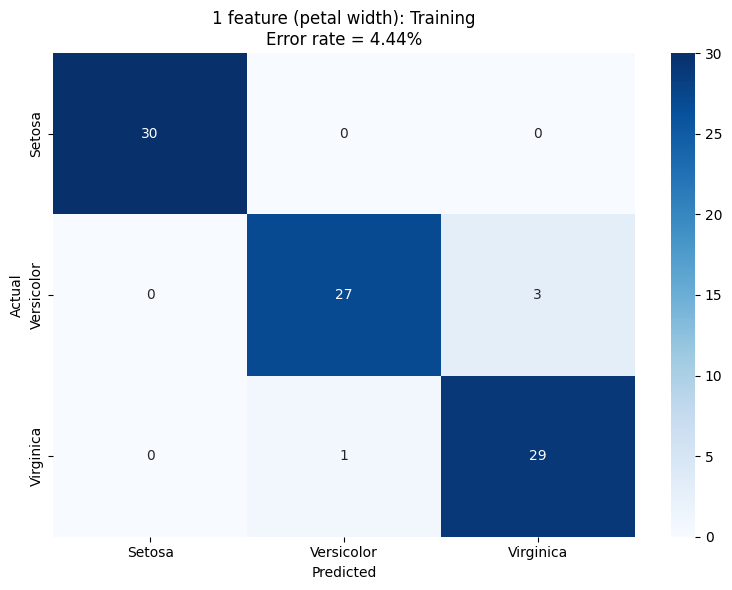

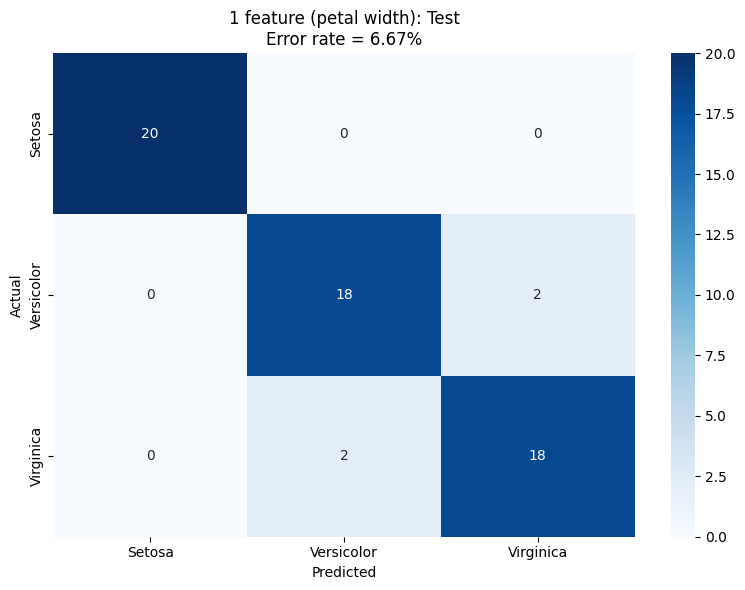

In [44]:
X_1 = X[:,[3]]

results1, best_alpha1, best_res1 = run_case(
    X_1, y,
    split_first30_last20,
    alphas,
    "1 feature (petal width)"
)

In [45]:
def print_alpha_results(results, case_name):
    print(f"\n {case_name} ")
    for alpha, res in results.items():
        print(
            f"alpha={alpha:<4}  "
            f"train_error={res['train_error']:.2%}  "
            f"test_error={res['test_error']:.2%}  "
            f"final_mse={res['mse_history'][-1]:.6f}  "
            f"iterations={res['iterations']}"
        )
        
print_alpha_results(results2, "2 features")
print_alpha_results(results1, "1 feature")


 2 features 
alpha=0.1   train_error=28.89%  test_error=26.67%  final_mse=14.529369  iterations=1000
alpha=0.01  train_error=6.67%  test_error=6.67%  final_mse=12.132059  iterations=1000
alpha=0.001  train_error=26.67%  test_error=28.33%  final_mse=17.066981  iterations=1000
alpha=0.0001  train_error=51.11%  test_error=45.00%  final_mse=26.025657  iterations=1000
alpha=1e-05  train_error=66.67%  test_error=66.67%  final_mse=28.870070  iterations=1000

 1 feature 
alpha=0.1   train_error=4.44%  test_error=6.67%  final_mse=11.508918  iterations=1000
alpha=0.01  train_error=12.22%  test_error=8.33%  final_mse=12.941731  iterations=1000
alpha=0.001  train_error=27.78%  test_error=30.00%  final_mse=17.710484  iterations=1000
alpha=0.0001  train_error=40.00%  test_error=38.33%  final_mse=26.776786  iterations=1000
alpha=1e-05  train_error=66.67%  test_error=66.67%  final_mse=32.119994  iterations=1000
